In [60]:
!python --version

Python 3.12.13


In [61]:
# Librerías
from google.colab import drive
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Montamos Google Drive en Colab
from google.colab import drive
drive.mount('/content/drive')

# Ruta base de trabajo
RUTA_BASE = "/content/drive/MyDrive/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
# Importamos el dataset de Kaggle en formato csv
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Análisis exploratorio de datos (EDA)

In [63]:
# Dimensiones del dataset
df.shape

(5110, 12)

In [64]:
# Primeras observaciones
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [65]:
# Tipos de variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [66]:
# Comprobación de filas duplicadas
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 0


## Valores faltantes

Cálculo del número de NaN por columna

In [67]:
# Distribución inicial de smoking_status
df["smoking_status"].value_counts()

,count
smoking_status,
never smoked,1892
Unknown,1544
formerly smoked,885
smokes,789


In [68]:
# Consideramos los valores "Unknown" de smoking_status como NaN
df["smoking_status"] = df["smoking_status"].replace("Unknown", np.nan)

# Número y porcentaje de valores faltantes por variable
nan_por_columna = df.isna().sum().sort_values(ascending=False)
porcentaje_nan_por_columna = df.isna().mean().sort_values(ascending=False) * 100

# Resumen de valores faltantes
nan_columna_df = pd.DataFrame({
    'Num_NaN_Columna': nan_por_columna,
    'Porcentaje_Participantes': porcentaje_nan_por_columna.round(2)
    })
print(nan_columna_df)

                   Num_NaN_Columna  Porcentaje_Participantes
smoking_status                1544                     30.22
bmi                            201                      3.93
id                               0                      0.00
gender                           0                      0.00
hypertension                     0                      0.00
age                              0                      0.00
heart_disease                    0                      0.00
ever_married                     0                      0.00
Residence_type                   0                      0.00
work_type                        0                      0.00
avg_glucose_level                0                      0.00
stroke                           0                      0.00


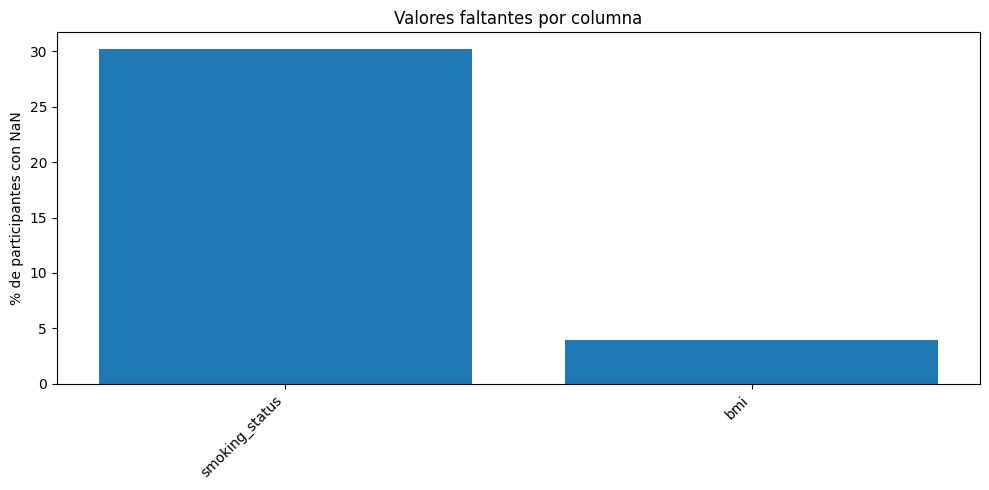

In [69]:
# Variables con presencia de NaN
nan_columna_df_plot = nan_columna_df[
    nan_columna_df['Num_NaN_Columna'] > 0]

# Visualización de valores faltantes
plt.figure(figsize=(10,5))
plt.bar(nan_columna_df_plot.index, nan_columna_df_plot['Porcentaje_Participantes'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('% de participantes con NaN')
plt.title('Valores faltantes por columna')
plt.tight_layout()
plt.show()

## Transformación de variables

In [70]:
# Variables categóricas y numéricas
var_categoricas = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'smoking_status']
var_numericas = ['age', 'avg_glucose_level', 'bmi']

Transformamos las variables categóricas en factores

In [71]:
# Género
df["gender"] = df["gender"].replace({
    "Male": "Hombre",
    "Female": "Mujer",
    "Other": np.nan
}).astype("category")

# Hipertensión
df["hypertension"] = df["hypertension"].map({
    0: "No",
    1: "Sí"
}).astype("category")

# Enfermedad cardiaca
df["heart_disease"] = df["heart_disease"].map({
    0: "No",
    1: "Sí"
}).astype("category")

# Estado civil
df["ever_married"] = df["ever_married"].map({
    "No": "No",
    "Yes": "Sí"
}).astype("category")

# Tipo de empleo
df["work_type"] = df["work_type"].replace({
    "children": "Niño",
    "Govt_job": "Empleado público",
    "Never_worked": "Nunca trabajó",
    "Private": "Sector privado",
    "Self-employed": "Autónomo"
}).astype("category")

# Tipo de residencia
df = df.rename(columns={"Residence_type": "residence_type"})
df["residence_type"] = df["residence_type"].map({
    "Rural": "Rural",
    "Urban": "Urbano"
}).astype("category")

# Tabaquismo
df["smoking_status"] = df["smoking_status"].replace({
    "formerly smoked": "Exfumador",
    "never smoked": "Nunca fumó",
    "smokes": "Fumador",
    "Unknown": np.nan
}).astype("category")

# Ictus (Variable objetivo)
df["stroke"] = df["stroke"].map({
    0: "No",
    1: "Sí"
}).astype("category")

## Estadísticas descriptivas

### Variable objetivo

In [72]:
# Frecuencias de la variable Stroke
print(df['stroke'].value_counts())
print((df['stroke'].value_counts(normalize=True) * 100).round(2))

stroke
No    4861
Sí     249
Name: count, dtype: int64
stroke
No    95.13
Sí     4.87
Name: proportion, dtype: float64


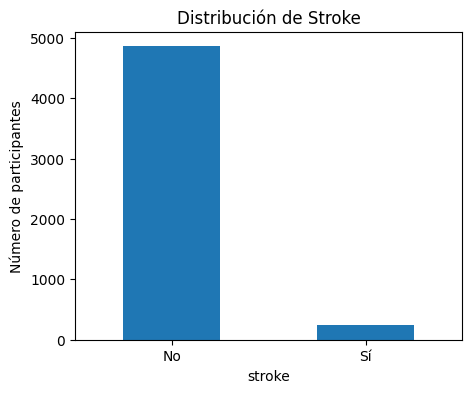

In [73]:
# Distribución de la variable objetivo
plt.figure(figsize=(5,4))
df['stroke'].value_counts().plot(kind='bar')
plt.title("Distribución de Stroke")
plt.ylabel("Número de participantes")
plt.xticks(rotation=0)
plt.show()

### Variables numéricas

In [74]:
# Estadísticas descriptivas
df[var_numericas].describe().round(2)

,age,avg_glucose_level,bmi
count,5110.00,5110.00,4909.00
mean,43.23,106.15,28.89
std,22.61,45.28,7.85
min,0.08,55.12,10.30
25%,25.00,77.24,23.50
50%,45.00,91.88,28.10
75%,61.00,114.09,33.10
max,82.00,271.74,97.60


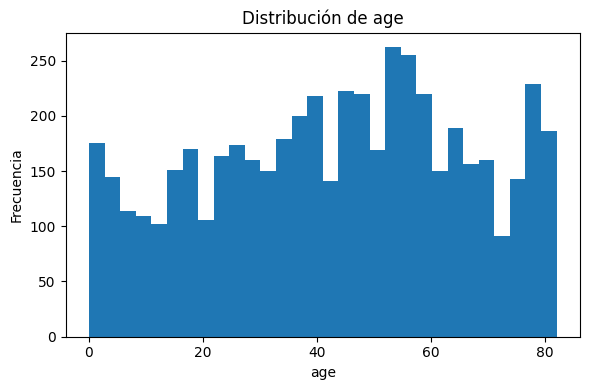

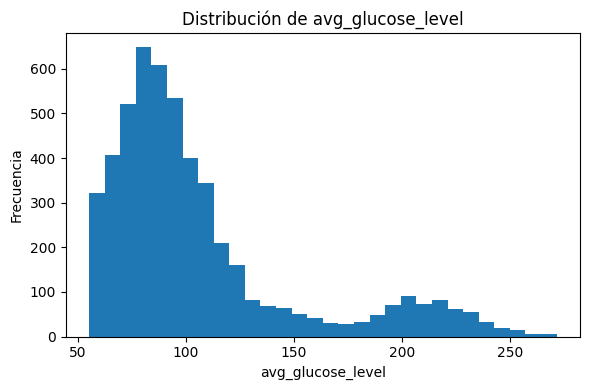

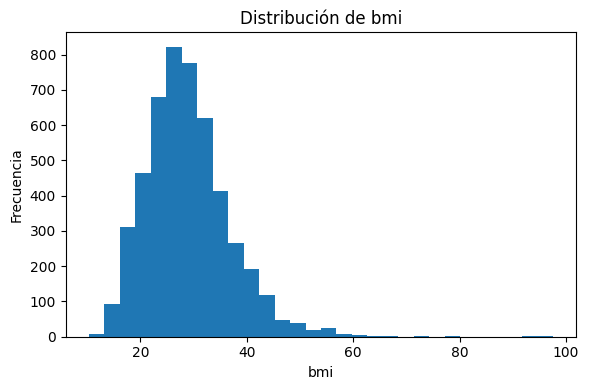

In [75]:
# Histogramas
for col in var_numericas:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

#### Detección de outliers

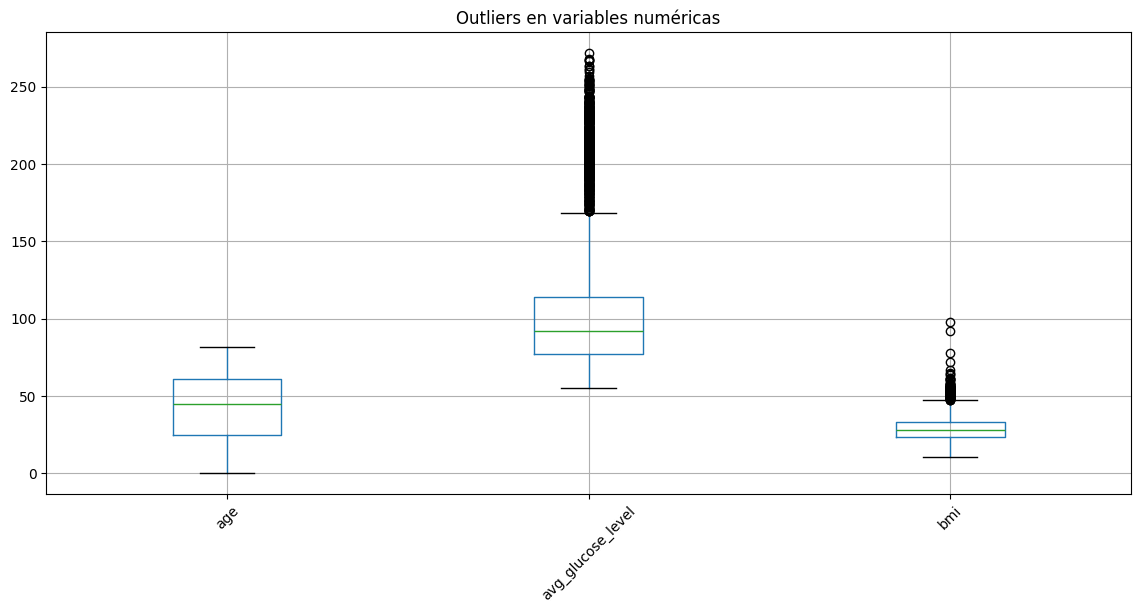

In [76]:
# Boxplot variables numéricas
df[var_numericas].boxplot(figsize=(14,6), rot=45)
plt.title("Outliers en variables numéricas")
plt.show()

#### Correlaciones entre variables numéricas

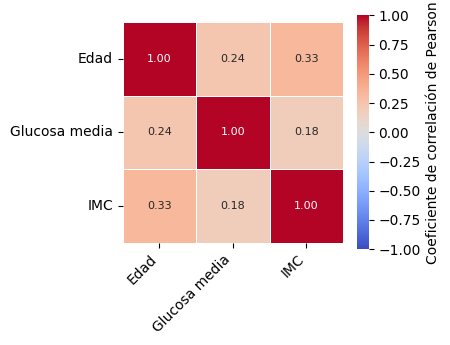

In [77]:
def matriz_correlacion(df, columnas, etiquetas=None, metodo="pearson",
                       anotar=True, figsize=(10, 9), enmascarar=True, nombre_archivo=None):
    corr = df[columnas].corr(method=metodo)
    if etiquetas:
        corr.index = etiquetas; corr.columns = etiquetas
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1) if enmascarar else None
    plt.figure(figsize=figsize)
    sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, annot=anotar, fmt=".2f",
                annot_kws={"fontsize": 8},
                cbar_kws={"label": f"Coeficiente de correlación de {metodo.capitalize()}",
                          "shrink": 0.8})
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()
    if nombre_archivo:
        plt.savefig(RUTA_BASE + nombre_archivo, dpi=300, bbox_inches="tight")
    plt.show()

# Kaggle (3 variables, anotada y pequeña)
matriz_correlacion(df, ["age", "avg_glucose_level", "bmi"],
                   etiquetas=["Edad", "Glucosa media", "IMC"],
                   anotar=True, enmascarar=False, figsize=(4.5, 4),
                   nombre_archivo="figura_anexo_corr_kaggle.png")

### Variables categóricas

#### Count plot

gender
Mujer     2994
Hombre    2115
Name: count, dtype: int64


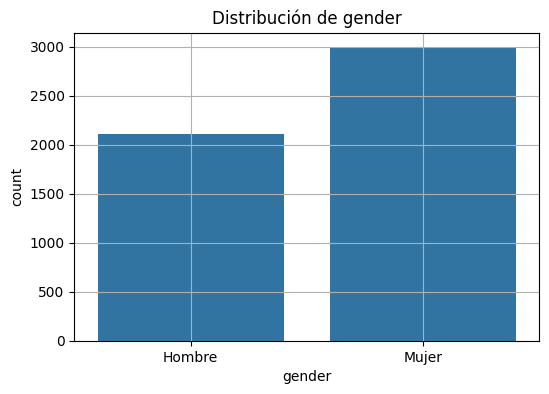

hypertension
No    4612
Sí     498
Name: count, dtype: int64


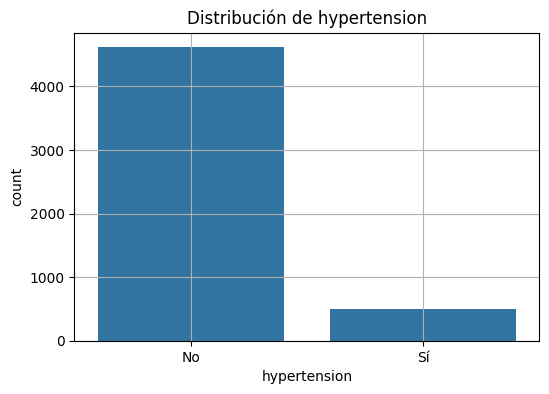

heart_disease
No    4834
Sí     276
Name: count, dtype: int64


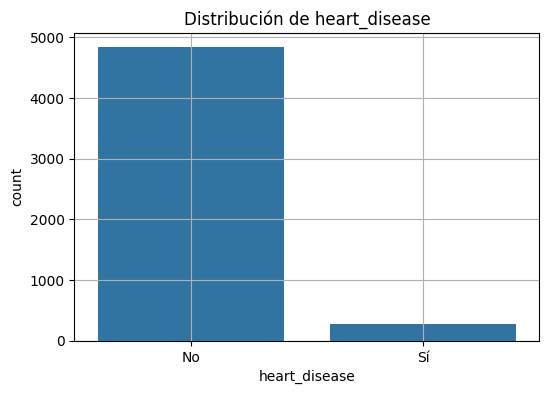

ever_married
Sí    3353
No    1757
Name: count, dtype: int64


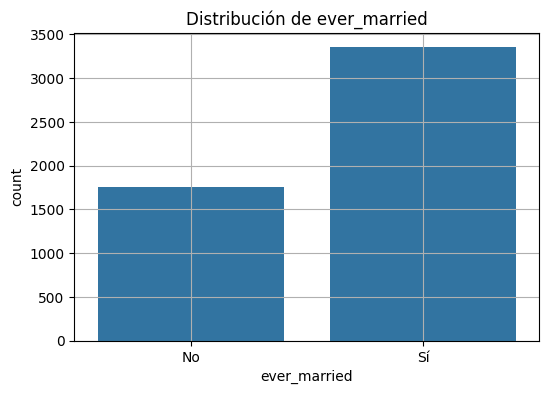

work_type
Sector privado      2925
Autónomo             819
Niño                 687
Empleado público     657
Nunca trabajó         22
Name: count, dtype: int64


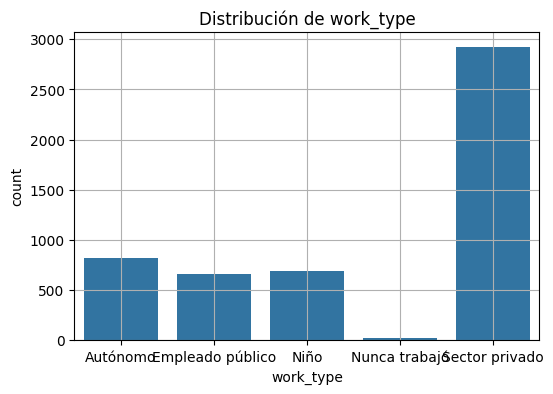

residence_type
Urbano    2596
Rural     2514
Name: count, dtype: int64


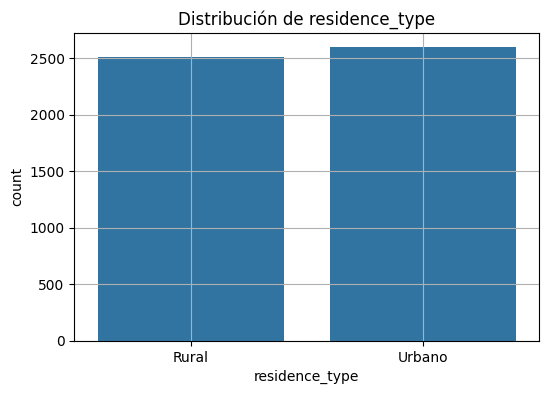

smoking_status
Nunca fumó    1892
Exfumador      885
Fumador        789
Name: count, dtype: int64


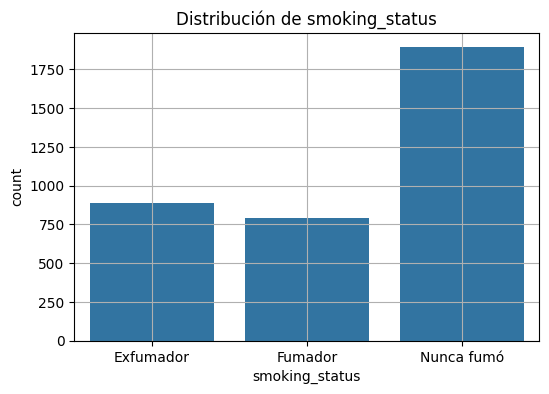

In [78]:
for col in var_categoricas:
    print(df[col].value_counts())

    fig, ax = plt.subplots(figsize=(6,4))
    sns.countplot(data=df, x=col, ax=ax)

    ax.set_title(f"Distribución de {col}")
    ax.grid(True)

    plt.show()

## Relación entre variables individuales y Stroke

### Variables numéricas vs Stroke

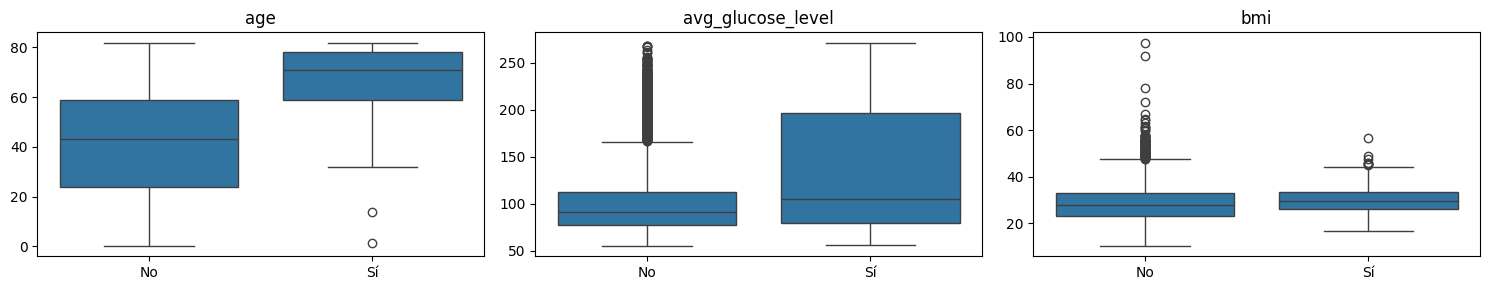

In [79]:
n_cols = 3
n_rows = int(np.ceil(len(var_numericas) / n_cols))

plt.figure(figsize=(15, 3*n_rows))

for i, col in enumerate(var_numericas):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(x='stroke', y=col, data=df)
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### Variables categóricas vs Stroke


gender vs Stroke (%)
stroke    Sí     No
gender             
Hombre  5.11  94.89
Mujer   4.71  95.29


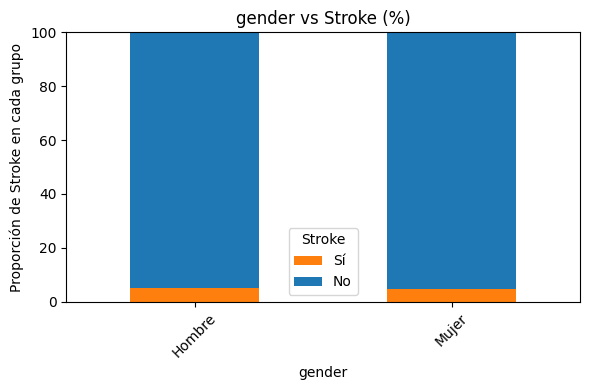


hypertension vs Stroke (%)
stroke           Sí     No
hypertension              
No             3.97  96.03
Sí            13.25  86.75


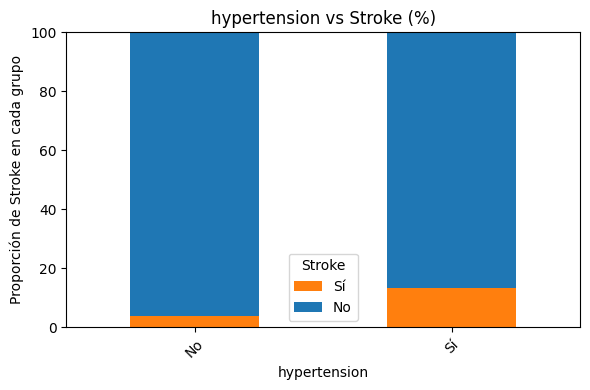


heart_disease vs Stroke (%)
stroke            Sí     No
heart_disease              
No              4.18  95.82
Sí             17.03  82.97


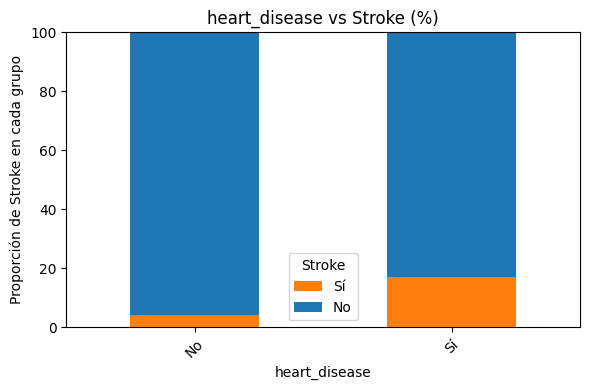


ever_married vs Stroke (%)
stroke          Sí     No
ever_married             
No            1.65  98.35
Sí            6.56  93.44


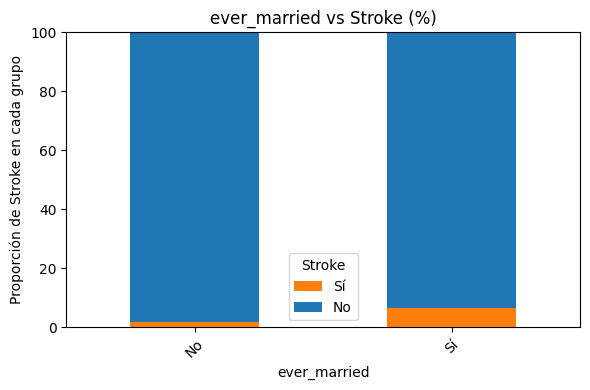


work_type vs Stroke (%)
stroke              Sí      No
work_type                     
Autónomo          7.94   92.06
Empleado público  5.02   94.98
Niño              0.29   99.71
Nunca trabajó     0.00  100.00
Sector privado    5.09   94.91


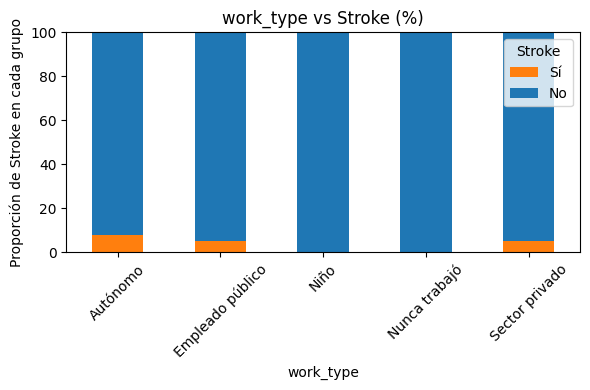


residence_type vs Stroke (%)
stroke            Sí     No
residence_type             
Rural           4.53  95.47
Urbano          5.20  94.80


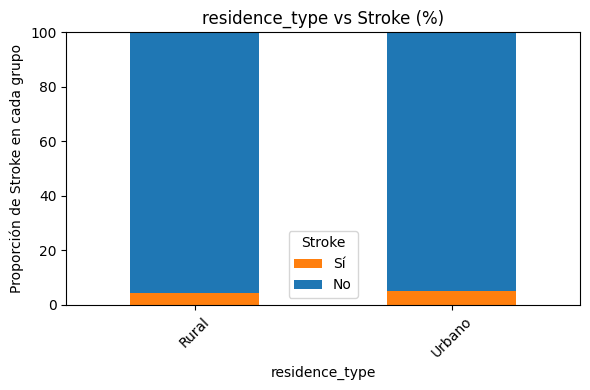


smoking_status vs Stroke (%)
stroke            Sí     No
smoking_status             
Exfumador       7.91  92.09
Fumador         5.32  94.68
Nunca fumó      4.76  95.24


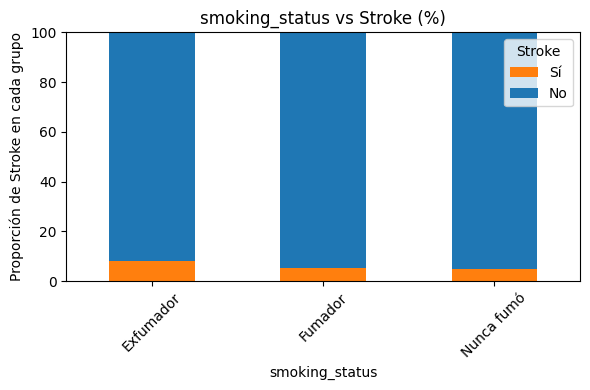

In [80]:
# Colores azul y naranja
colors = ['#ff7f0e', '#1f77b4']  # azul para Stroke Sí, naranja para Stroke No

for col in var_categoricas:
    if col != "stroke":
        # Tabla de porcentajes por fila (cada categoría suma 100%)
        tabla = pd.crosstab(df[col], df["stroke"], normalize='index') * 100
        tabla = tabla[['Sí', 'No']]  # Aseguramos el mismo orden de columnas
        print(f"\n{col} vs Stroke (%)")
        print(tabla.round(2))

        # Gráfico de barras apiladas usando la misma tabla
        ax = tabla.plot(kind='bar', stacked=True, figsize=(6,4), color=colors)
        plt.title(f"{col} vs Stroke (%)")
        plt.ylabel("Proporción de Stroke en cada grupo")
        plt.xlabel(col)
        plt.xticks(rotation=45)
        plt.ylim(0,100)
        plt.legend(title='Stroke')
        plt.tight_layout()
        plt.show()

In [81]:
# Guardado y exportación del dataset final listo para el preprocesado
df_prep = df.copy()

drive.mount('/content/drive', force_remount=True)
df_prep.to_csv("/content/drive/MyDrive/df_prep.csv", index=False)

Mounted at /content/drive
